## Imports

In [10]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from abm_simulator import ABMSimulator
from flood_adapt import FloodAdapt
from flood_adapt.config.config import Settings

## Config

In [ ]:
# FloodAdapt databse inputs
# DATA_DIR = Path(r"c:\Users\athanasi\Github\Database\Working_Databases\Charleston\4_FloodAdapt\Database")
DATA_DIR = Path(r"c:\Users\winter_ga\Offline_data\FloodAdapt-WorkingDatabase\Charleston\4_FloodAdapt\Database")

site = "charleston_beta_release"

# Monte Carlo input parameters for event sequences
timestep = 1  # timestep of Monte Carlo in years
sim_time = 30  # length of simulation in years
no_seq = 100  # number of event sequences to generate
seed = 42  # random seed for reproducibility

# SLR scenario to evaluate damages over time
slr_scenario_name = "NOAA High" # This needs to be a scenario in the FloodAdapt database

# lookup table
ds_impacts = xr.open_dataset("lookup_table_charleston.nc")

In [12]:
times = 2020 + np.linspace(0, sim_time, int(sim_time / timestep) + 1)
times

array([2020., 2021., 2022., 2023., 2024., 2025., 2026., 2027., 2028.,
       2029., 2030., 2031., 2032., 2033., 2034., 2035., 2036., 2037.,
       2038., 2039., 2040., 2041., 2042., 2043., 2044., 2045., 2046.,
       2047., 2048., 2049., 2050.])

## Initialize FloodAdapt Database

In [13]:
settings = Settings(
    DATABASE_ROOT=DATA_DIR,
    DATABASE_NAME=site,
)
fa = FloodAdapt(database_path=settings.database_path)
slr_values = [fa.interp_slr(slr_scenario=slr_scenario_name, year=time) for time in times]

In [14]:
ds_impacts

<xarray.Dataset> Size: 427MB
Dimensions:       (object_id: 61858, slr: 4, strategy: 2, event: 4)
Coordinates:
  * object_id     (object_id) <U1598 395MB '14048' '67199' ... '70438' '70444'
  * slr           (slr) int32 16B 0 1 2 3
  * strategy      (strategy) <U16 128B 'no_measures' 'floodproof_all_0'
  * event         (event) <U10 160B 'subevent_1' 'subevent_2' ... 'subevent_4'
Data variables:
    inun_depth    (object_id, slr, strategy, event) float64 16MB ...
    total_damage  (object_id, slr, strategy, event) float64 16MB ...

In [15]:
from abm_simulator import ABMSimulator  

# Instantiate the simulator (event sequence and damage lookup are handled internally)
abm = ABMSimulator(
    ds_impacts=ds_impacts,
    times=times,
    slr_values=slr_values,
    no_seq=no_seq,
    damage_threshold=0.3,  # You can change this threshold as needed
    seed=seed
)


In [16]:
# Run the simulation
abm.run("floor ")


[BASELINE] Evaluating sequence 1/200...
[BASELINE] Evaluating sequence 2/200...
[BASELINE] Evaluating sequence 3/200...
[BASELINE] Evaluating sequence 4/200...
[BASELINE] Evaluating sequence 5/200...
[BASELINE] Evaluating sequence 6/200...
[BASELINE] Evaluating sequence 7/200...
[BASELINE] Evaluating sequence 8/200...
[BASELINE] Evaluating sequence 9/200...
[BASELINE] Evaluating sequence 10/200...
[BASELINE] Evaluating sequence 11/200...
[BASELINE] Evaluating sequence 12/200...
[BASELINE] Evaluating sequence 13/200...
[BASELINE] Evaluating sequence 14/200...
[BASELINE] Evaluating sequence 15/200...
[BASELINE] Evaluating sequence 16/200...
[BASELINE] Evaluating sequence 17/200...
[BASELINE] Evaluating sequence 18/200...
[BASELINE] Evaluating sequence 19/200...
[BASELINE] Evaluating sequence 20/200...
[BASELINE] Evaluating sequence 21/200...
[BASELINE] Evaluating sequence 22/200...
[BASELINE] Evaluating sequence 23/200...
[BASELINE] Evaluating sequence 24/200...
[BASELINE] Evaluating seq

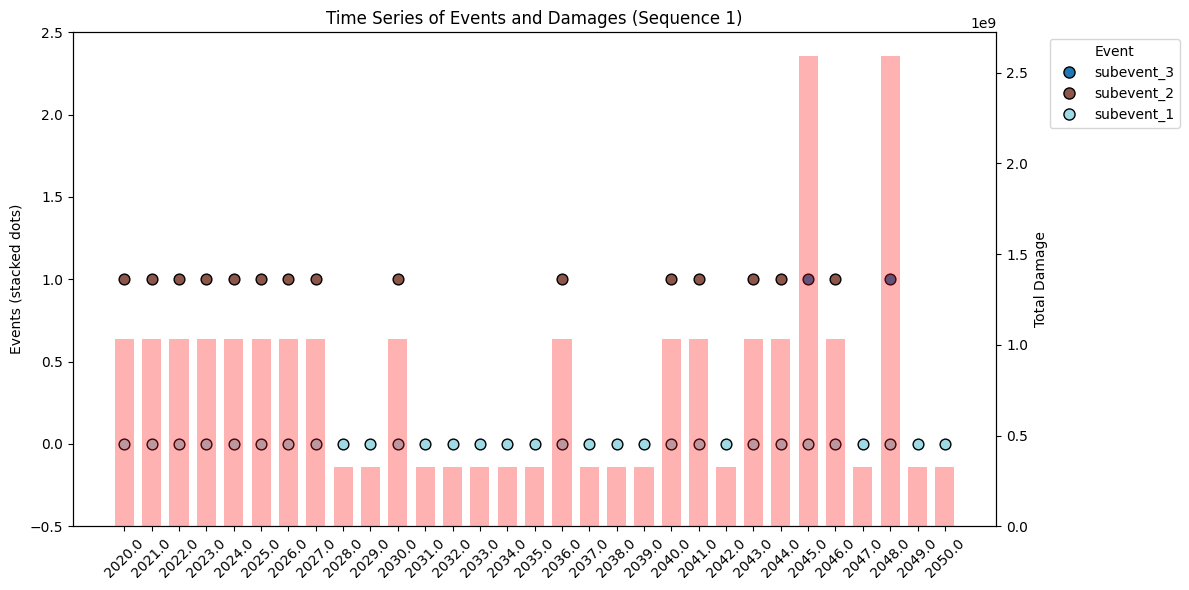

In [18]:
abm.plot_event_damage_timeseries(1)

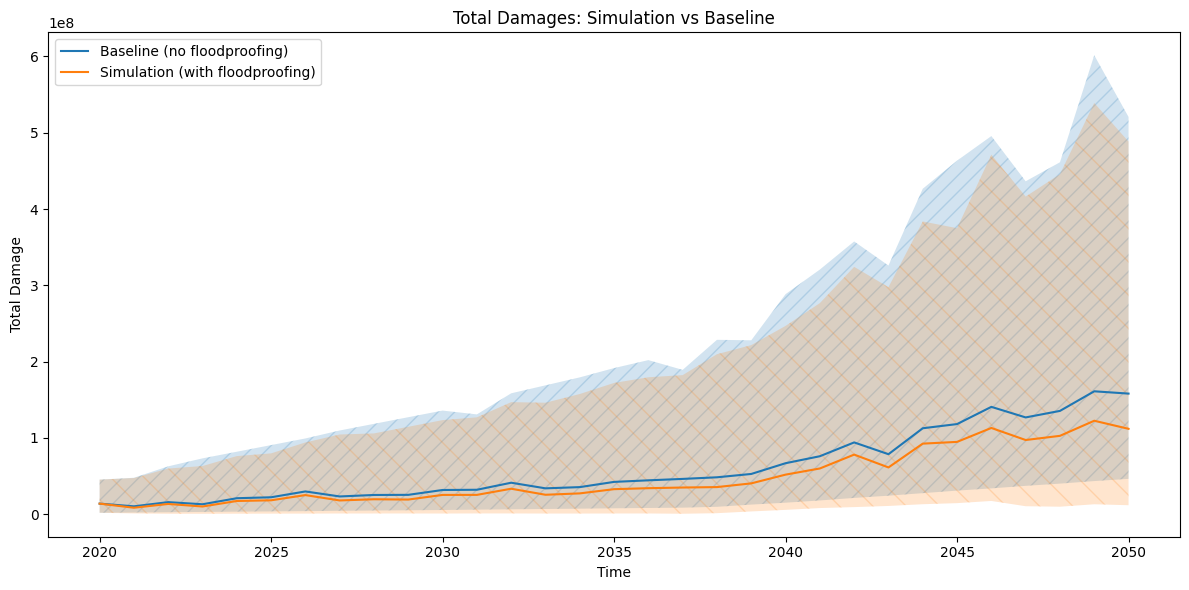

In [19]:
abm.plot_total_damage_statistics()